In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

df = pd.read_csv('dataset/blockchain_transactions.csv')

print(f"Shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Shape: (10206, 13)
Memory: 5.74 MB


In [2]:
print("=== INFO ===")
df.info()

print("\n=== 5 BARIS PERTAMA ===")
print(df.head())

print("\n=== 5 BARIS ACAK ===")
print(df.sample(5, random_state=42))

=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 10206 entries, 0 to 10205
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   block_index          10206 non-null  int64  
 1   block_timestamp      10206 non-null  float64
 2   block_miner_id       10206 non-null  str    
 3   tx_id                10205 non-null  str    
 4   tx_timestamp         10205 non-null  float64
 5   tx_type              10205 non-null  str    
 6   tx_sender            10205 non-null  str    
 7   tx_recipient         10205 non-null  str    
 8   tx_amount            10205 non-null  float64
 9   tx_energy            10205 non-null  float64
 10  block_hash           10206 non-null  str    
 11  block_previous_hash  10206 non-null  str    
 12  block_nonce          10206 non-null  int64  
dtypes: float64(4), int64(2), str(7)
memory usage: 1.0 MB

=== 5 BARIS PERTAMA ===
   block_index    block_timestamp block_miner_id  \
0   

In [3]:
print("=== MISSING VALUES ===")
missing = pd.DataFrame({
    'n_missing': df.isnull().sum(),
    'pct_missing': df.isnull().mean() * 100
})
print(missing[missing['n_missing'] > 0] if missing['n_missing'].sum() > 0 
      else "Tidak ada missing values")

print(f"\n=== DUPLIKAT ===")
print(f"Baris duplikat penuh: {df.duplicated().sum()}")

=== MISSING VALUES ===
              n_missing  pct_missing
tx_id                 1       0.0098
tx_timestamp          1       0.0098
tx_type               1       0.0098
tx_sender             1       0.0098
tx_recipient          1       0.0098
tx_amount             1       0.0098
tx_energy             1       0.0098

=== DUPLIKAT ===
Baris duplikat penuh: 0


In [4]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Kolom numerik ({len(num_cols)}): {num_cols}\n")

desc = df[num_cols].describe().T
desc['skew'] = df[num_cols].skew()
desc['kurtosis'] = df[num_cols].kurtosis()
print(desc)

Kolom numerik (6): ['block_index', 'block_timestamp', 'tx_timestamp', 'tx_amount', 'tx_energy', 'block_nonce']

                      count               mean        std                min  \
block_index     10,206.0000           243.3608   140.7881             0.0000   
block_timestamp 10,206.0000 1,753,188,308.4417 2,058.5122 1,753,184,695.0558   
tx_timestamp    10,205.0000 1,753,188,308.7876 2,058.2979 1,753,184,805.0682   
tx_amount       10,205.0000             0.1783     0.1318             0.0022   
tx_energy       10,205.0000             0.4454     0.6356             0.0000   
block_nonce     10,206.0000           261.1494   251.1525             0.0000   

                               25%                50%                75%  \
block_index               122.0000           240.0000           366.0000   
block_timestamp 1,753,186,522.6101 1,753,188,225.5560 1,753,190,109.1768   
tx_timestamp    1,753,186,522.6057 1,753,188,225.5473 1,753,190,109.1670   
tx_amount              

In [5]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Kolom non-numerik ({len(cat_cols)}): {cat_cols}\n")

for col in cat_cols:
    n_unique = df[col].nunique()
    print(f"--- {col} ---")
    print(f"  Unique: {n_unique} ({n_unique/len(df)*100:.1f}% dari total baris)")
    if n_unique <= 20:
        print(df[col].value_counts())
    else:
        print(f"  Top 5:\n{df[col].value_counts().head()}")
    print()

Kolom non-numerik (7): ['block_miner_id', 'tx_id', 'tx_type', 'tx_sender', 'tx_recipient', 'block_hash', 'block_previous_hash']

--- block_miner_id ---
  Unique: 2 (0.0% dari total baris)
block_miner_id
GRID-OP-01    10205
genesis           1
Name: count, dtype: int64

--- tx_id ---
  Unique: 10205 (100.0% dari total baris)
  Top 5:
tx_id
21eed0258f184cc8ab97382ff638b9a1    1
23268eea91b84e1b847115b1515c64e4    1
1b3cc40f30ce4fb7a5cfef36fe05e932    1
1d990f952b384f508c9b28583fc83959    1
23376b2b4f924d0db6e1503d811a6689    1
Name: count, dtype: int64

--- tx_type ---
  Unique: 2 (0.0% dari total baris)
tx_type
energy_delivery    5193
energy_payment     5012
Name: count, dtype: int64

--- tx_sender ---
  Unique: 23 (0.2% dari total baris)
  Top 5:
tx_sender
GRID-OP-01    5193
CON-03         436
CON-10         327
CON-17         289
CON-06         277
Name: count, dtype: int64

--- tx_recipient ---
  Unique: 30 (0.3% dari total baris)
  Top 5:
tx_recipient
PRO-05    848
PRO-02    835
PRO

C:\Users\Acer\AppData\Local\Temp\ipykernel_26028\3518603767.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


In [6]:
# Cari kolom yang kemungkinan timestamp
candidates = [c for c in df.columns if any(k in c.lower() 
              for k in ['time', 'date', 'stamp', 'block'])]
print(f"Kandidat kolom waktu: {candidates}\n")

for col in candidates:
    print(f"--- {col} ---")
    print(df[col].head(3).tolist())
    print(f"dtype: {df[col].dtype}\n")

Kandidat kolom waktu: ['block_index', 'block_timestamp', 'block_miner_id', 'tx_timestamp', 'block_hash', 'block_previous_hash', 'block_nonce']

--- block_index ---
[0, 1, 1]
dtype: int64

--- block_timestamp ---
[1753184695.0558405, 1753184805.068432, 1753184805.068432]
dtype: float64

--- block_miner_id ---
['genesis', 'GRID-OP-01', 'GRID-OP-01']
dtype: str

--- tx_timestamp ---
[nan, 1753184805.0681646, 1753184805.0681534]
dtype: float64

--- block_hash ---
['00a0c15fca506230353c4f5a8452da5fdbc6b4c5ad25ea33da766d6de553d968', '00b70fbea4dcce4d9d0d654feb04081376007cefd82d86c23c4187beb755da71', '00b70fbea4dcce4d9d0d654feb04081376007cefd82d86c23c4187beb755da71']
dtype: str

--- block_previous_hash ---
['0', '00a0c15fca506230353c4f5a8452da5fdbc6b4c5ad25ea33da766d6de553d968', '00a0c15fca506230353c4f5a8452da5fdbc6b4c5ad25ea33da766d6de553d968']
dtype: str

--- block_nonce ---
[886, 292, 292]
dtype: int64



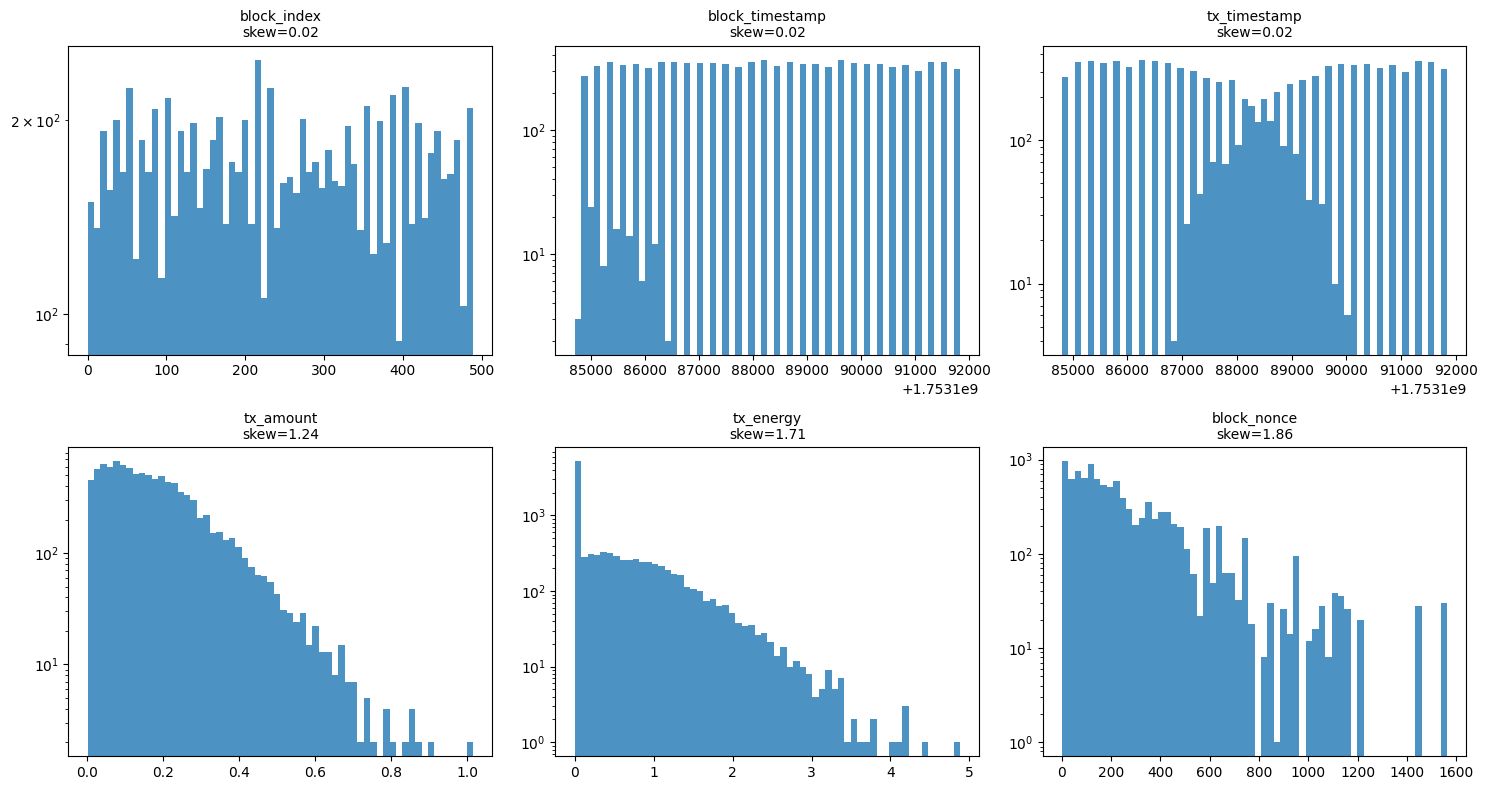

In [7]:
n = len(num_cols)
ncols = 3
nrows = -(-n // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = np.array(axes).flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=60, edgecolor='none', alpha=0.8)
    axes[i].set_title(f"{col}\nskew={df[col].skew():.2f}", fontsize=10)
    axes[i].set_yscale('log')  # <- penting, lihat penjelasan

for j in range(n, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

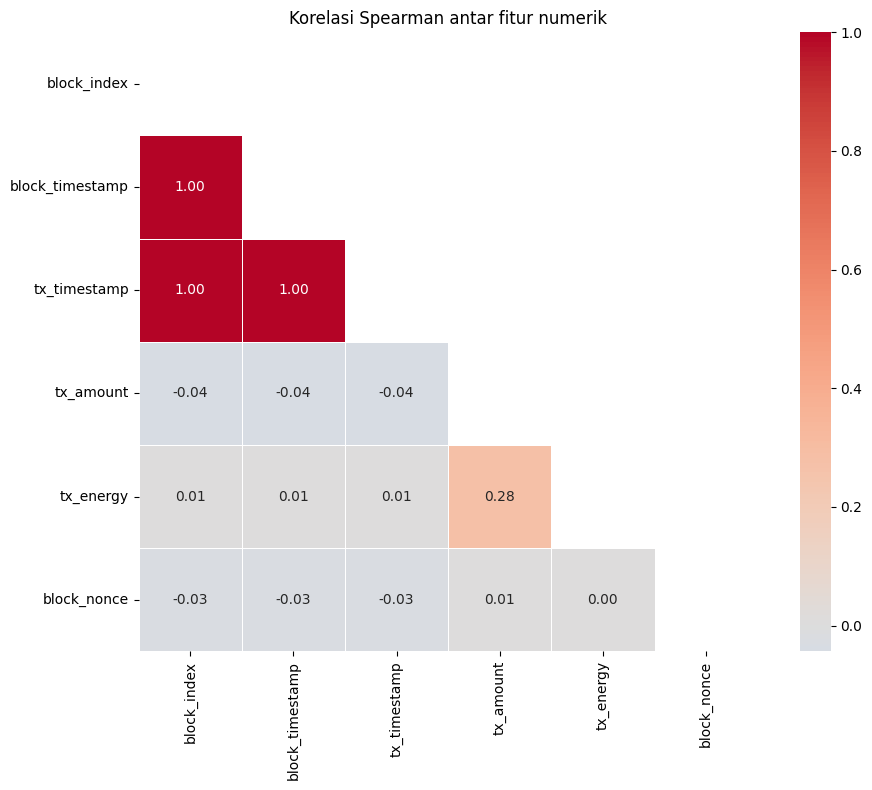

In [8]:
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Korelasi Spearman antar fitur numerik')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=100, bbox_inches='tight')
plt.show()

# Cell 9

In [9]:
# Pisahkan genesis dari transaksi
tx = df[df['tx_id'].notna()].copy()
print(f"Transaksi valid: {len(tx)}")

delivery = tx[tx['tx_type'] == 'energy_delivery']
payment  = tx[tx['tx_type'] == 'energy_payment']
print(f"Delivery: {len(delivery)}, Payment: {len(payment)}, Selisih: {len(delivery)-len(payment)}")

# Statistik terstratifikasi — bandingkan dengan Cell 4 yang tercampur
print("\n=== tx_amount per tipe ===")
print(tx.groupby('tx_type')['tx_amount'].describe())
print("\n=== tx_energy per tipe ===")
print(tx.groupby('tx_type')['tx_energy'].describe())

Transaksi valid: 10205
Delivery: 5193, Payment: 5012, Selisih: 181

=== tx_amount per tipe ===
                     count   mean    std    min    25%    50%    75%    max
tx_type                                                                    
energy_delivery 5,193.0000 0.1792 0.1325 0.0022 0.0780 0.1536 0.2486 1.0154
energy_payment  5,012.0000 0.1773 0.1311 0.0022 0.0769 0.1521 0.2464 1.0154

=== tx_energy per tipe ===
                     count   mean    std    min    25%    50%    75%    max
tx_type                                                                    
energy_delivery 5,193.0000 0.8753 0.6461 0.0109 0.3797 0.7506 1.2147 4.8825
energy_payment  5,012.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000


count   5,193.0000
mean        0.2047
std         0.0037
min         0.1995
25%         0.2020
50%         0.2047
75%         0.2072
max         0.2907
dtype: float64

Coefficient of variation: 1.79%


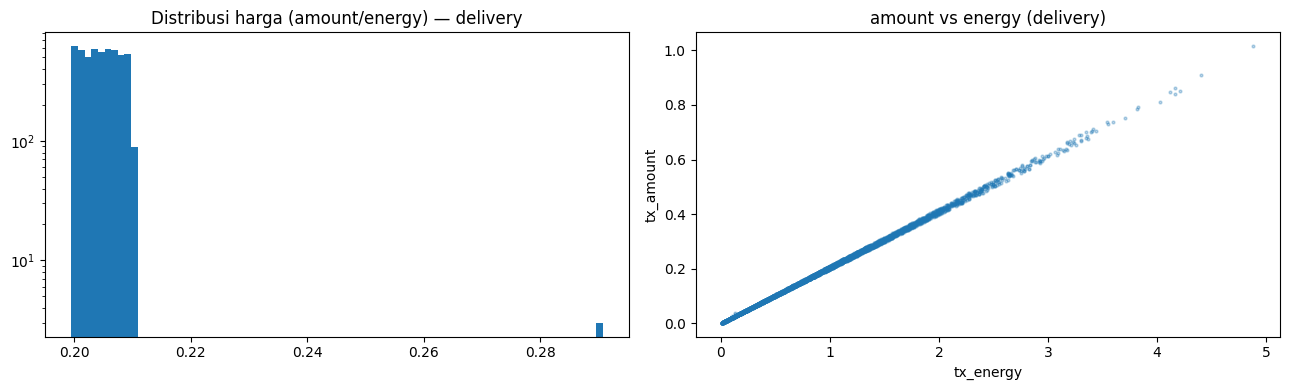


Delivery dengan deviasi harga >5% dari median: 3
Delivery dengan deviasi harga >20% dari median: 3


In [10]:
price = delivery['tx_amount'] / delivery['tx_energy']
print(price.describe())
print(f"\nCoefficient of variation: {price.std()/price.mean()*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(price, bins=80)
axes[0].set_yscale('log')
axes[0].set_title('Distribusi harga (amount/energy) — delivery')

axes[1].scatter(delivery['tx_energy'], delivery['tx_amount'], s=4, alpha=0.3)
axes[1].set_xlabel('tx_energy'); axes[1].set_ylabel('tx_amount')
axes[1].set_title('amount vs energy (delivery)')
plt.tight_layout(); plt.show()

# Berapa banyak yang menyimpang dari harga median?
dev = (price - price.median()).abs() / price.median()
print(f"\nDelivery dengan deviasi harga >5% dari median: {(dev > 0.05).sum()}")
print(f"Delivery dengan deviasi harga >20% dari median: {(dev > 0.20).sum()}")

In [11]:
# Hipotesis: tiap delivery (GRID→CON-x) berpasangan dengan payment (CON-x→PRO-y)
# dengan tx_amount identik, di blok yang sama atau berdekatan
merged = delivery.merge(
    payment,
    left_on=['tx_recipient', 'tx_amount'],   # konsumen penerima energi
    right_on=['tx_sender', 'tx_amount'],     # konsumen pembayar
    suffixes=('_del', '_pay'),
    how='left'
)
n_unpaired = merged['tx_id_pay'].isna().sum()
print(f"Delivery tanpa payment yang cocok (recipient+amount): {n_unpaired}")

# Siapa konsumen yang paling sering tidak membayar?
unpaired = merged[merged['tx_id_pay'].isna()]
print("\nKonsumen dengan delivery tak berpasangan:")
print(unpaired['tx_recipient_del'].value_counts().head(10))

# Kapan delivery tak berpasangan ini terjadi?
print("\nRentang waktu delivery tak berpasangan:")
print(f"  min: {unpaired['tx_timestamp_del'].min():,.0f}")
print(f"  max: {unpaired['tx_timestamp_del'].max():,.0f}")

Delivery tanpa payment yang cocok (recipient+amount): 181

Konsumen dengan delivery tak berpasangan:
tx_recipient_del
CON-09    181
Name: count, dtype: int64

Rentang waktu delivery tak berpasangan:
  min: 1,753,188,471
  max: 1,753,191,833


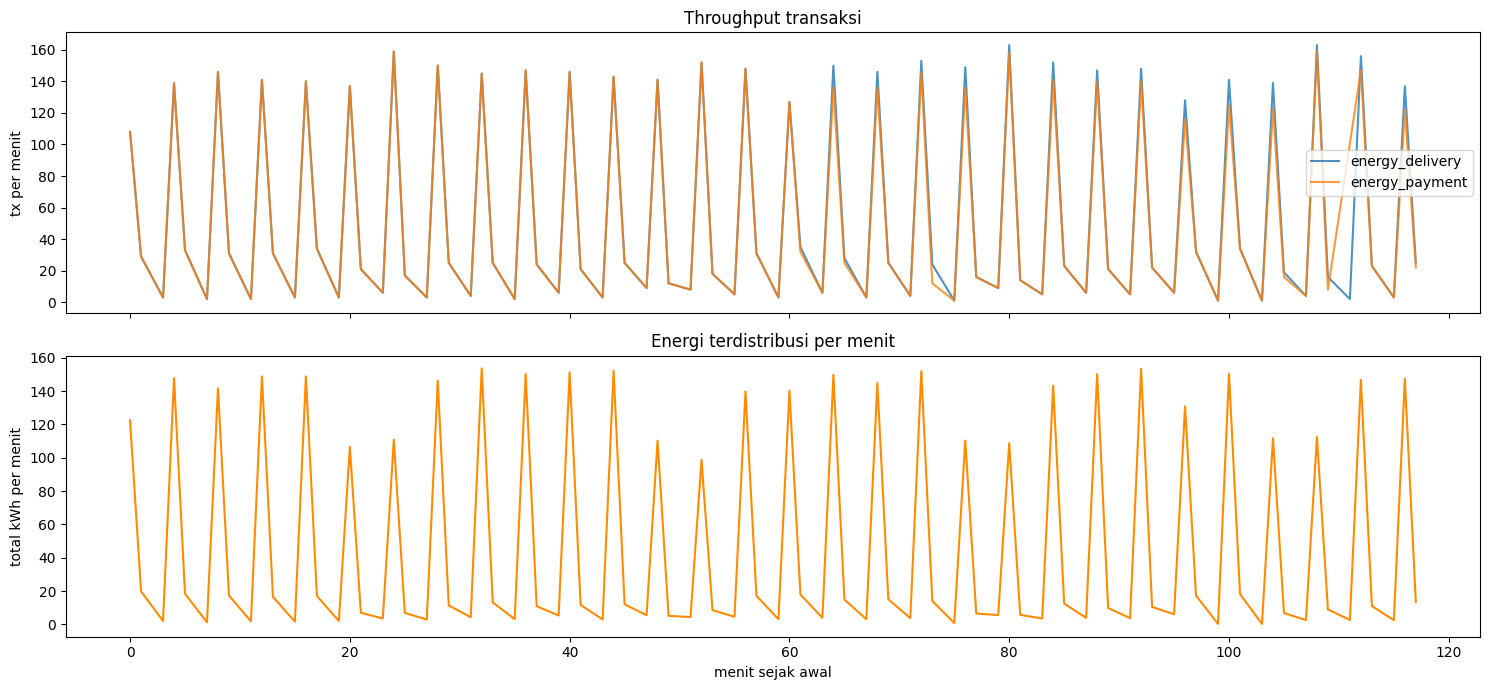

In [12]:
t0 = tx['tx_timestamp'].min()
tx['t_rel'] = tx['tx_timestamp'] - t0  # detik sejak awal simulasi

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

# Throughput per menit, per tipe
for ttype, ax_data in tx.groupby('tx_type'):
    counts = ax_data.groupby((ax_data['t_rel'] // 60).astype(int)).size()
    axes[0].plot(counts.index, counts.values, label=ttype, alpha=0.8)
axes[0].set_ylabel('tx per menit'); axes[0].legend(); axes[0].set_title('Throughput transaksi')

# Total energi terkirim per menit
energy_per_min = delivery.assign(t_rel=delivery['tx_timestamp']-t0) \
    .groupby(lambda i: int((delivery.loc[i,'tx_timestamp']-t0)//60))['tx_energy'].sum() \
    if False else \
    delivery.assign(minute=((delivery['tx_timestamp']-t0)//60).astype(int)) \
    .groupby('minute')['tx_energy'].sum()
axes[1].plot(energy_per_min.index, energy_per_min.values, color='darkorange')
axes[1].set_ylabel('total kWh per menit'); axes[1].set_xlabel('menit sejak awal')
axes[1].set_title('Energi terdistribusi per menit')
plt.tight_layout(); plt.show()

In [13]:
con_profile = pd.DataFrame({
    'n_delivery_diterima': delivery.groupby('tx_recipient').size(),
    'total_energy': delivery.groupby('tx_recipient')['tx_energy'].sum(),
    'n_payment_dikirim': payment.groupby('tx_sender').size(),
    'total_dibayar': payment.groupby('tx_sender')['tx_amount'].sum(),
    'total_tagihan': delivery.groupby('tx_recipient')['tx_amount'].sum(),
}).fillna(0)
con_profile['selisih_bayar'] = con_profile['total_tagihan'] - con_profile['total_dibayar']
con_profile['rasio_bayar'] = con_profile['total_dibayar'] / con_profile['total_tagihan']
print(con_profile.sort_values('rasio_bayar'))

        n_delivery_diterima  total_energy  n_payment_dikirim  total_dibayar  \
CON-09                  418      475.6337                237        55.4653   
CON-00                  254      243.7067                254        49.8526   
CON-02                  196      138.1062                196        28.3051   
CON-01                  243      181.6740                243        37.1723   
CON-04                  257      244.5715                257        50.1048   
CON-05                  237      204.4841                237        41.9392   
CON-06                  277      257.7482                277        52.7105   
CON-03                  436      556.3311                436       114.0517   
CON-07                  172       98.4910                172        20.1595   
CON-08                  263      201.1467                263        41.1367   
CON-10                  327      351.7561                327        71.9790   
CON-11                  195      132.4896           

count   10,205.0000
mean         0.0081
std          0.0050
min          0.0003
25%          0.0040
50%          0.0077
75%          0.0117
max          0.0241
Name: latency, dtype: float64

Latency negatif (tx 'setelah' blok — mustahil secara kausal): 0


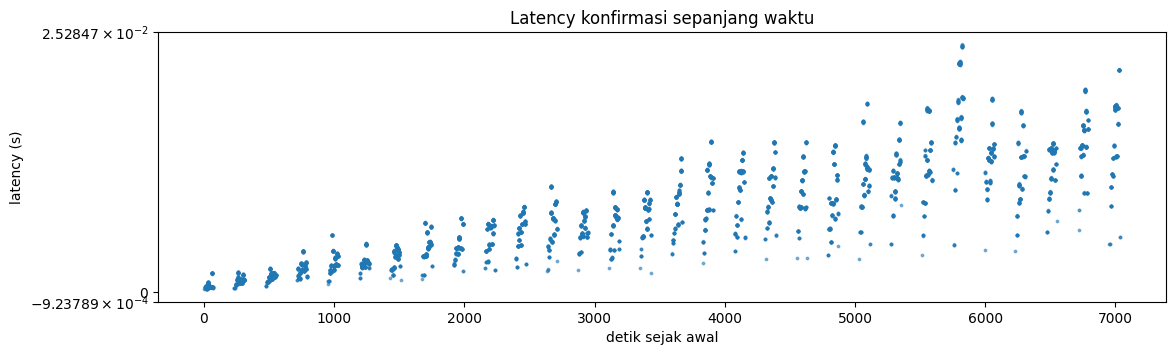


Blok dengan rantai putus: 0 dari 489


In [14]:
tx['latency'] = tx['block_timestamp'] - tx['tx_timestamp']
print(tx['latency'].describe())
print(f"\nLatency negatif (tx 'setelah' blok — mustahil secara kausal): {(tx['latency'] < 0).sum()}")

plt.figure(figsize=(13, 3.5))
plt.scatter(tx['t_rel'], tx['latency'], s=3, alpha=0.3)
plt.xlabel('detik sejak awal'); plt.ylabel('latency (s)')
plt.title('Latency konfirmasi sepanjang waktu')
plt.yscale('symlog')
plt.show()

# Verifikasi integritas rantai: previous_hash blok n == hash blok n-1?
blocks = df.drop_duplicates('block_index').sort_values('block_index')
chain_ok = (blocks['block_previous_hash'].iloc[1:].values == 
            blocks['block_hash'].iloc[:-1].values)
print(f"\nBlok dengan rantai putus: {(~chain_ok).sum()} dari {len(chain_ok)}")

# Cell 15

In [15]:
delivery = delivery.copy()
delivery['price'] = delivery['tx_amount'] / delivery['tx_energy']
med = delivery['price'].median()

suspects = delivery[(delivery['price'] - med).abs() / med > 0.20]
print(suspects[['block_index', 'tx_timestamp', 'tx_recipient', 
                'tx_amount', 'tx_energy', 'price']])

# Konversi ke menit-relatif agar bisa dibandingkan dengan timeline CON-09
t0 = tx['tx_timestamp'].min()
print("\nMenit kejadian:", ((suspects['tx_timestamp'] - t0) / 60).round(1).tolist())

       block_index       tx_timestamp tx_recipient  tx_amount  tx_energy  \
3765           177 1,753,187,278.9145       CON-19     0.0369     0.1272   
5156           243 1,753,188,240.6329       CON-09     0.0364     0.1254   
10202          489 1,753,191,838.3388       CON-10     0.0291     0.1002   

       price  
3765  0.2901  
5156  0.2907  
10202 0.2905  

Menit kejadian: [41.2, 57.3, 117.2]


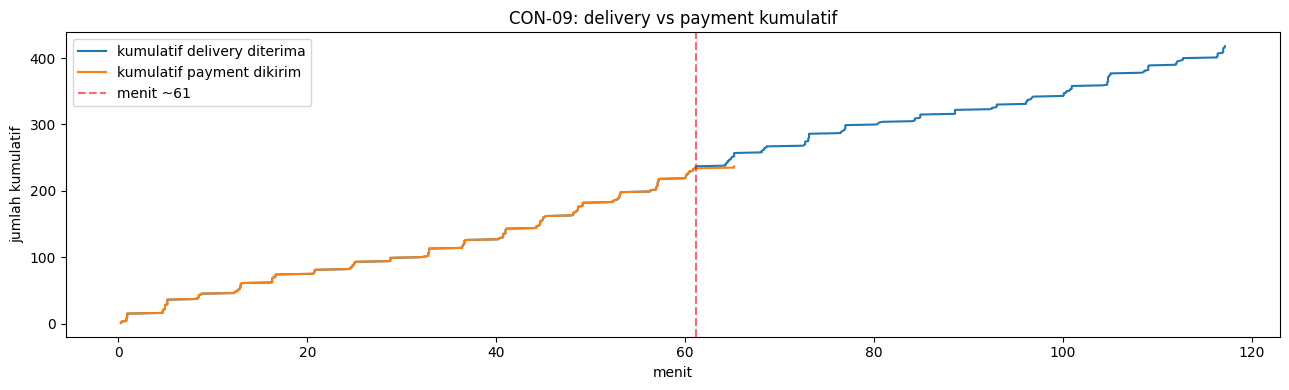

                   count   mean      sum
fase                                    
sebelum (bayar)      233 1.1592 270.0974
sesudah (nunggak)    185 1.1110 205.5364

Laju delivery per menit:
  sebelum: 3.81 delivery/menit
  sesudah: 3.30 delivery/menit


In [16]:
con9_del = delivery[delivery['tx_recipient'] == 'CON-09'].sort_values('tx_timestamp')
con9_pay = payment[payment['tx_sender'] == 'CON-09'].sort_values('tx_timestamp')

plt.figure(figsize=(13, 4))
plt.plot((con9_del['tx_timestamp']-t0)/60, np.arange(1, len(con9_del)+1), 
         label='kumulatif delivery diterima')
plt.plot((con9_pay['tx_timestamp']-t0)/60, np.arange(1, len(con9_pay)+1), 
         label='kumulatif payment dikirim')
plt.axvline(61.1, color='red', ls='--', alpha=0.6, label='menit ~61')
plt.xlabel('menit'); plt.ylabel('jumlah kumulatif')
plt.title('CON-09: delivery vs payment kumulatif')
plt.legend(); plt.tight_layout(); plt.show()

# Apakah konsumsinya berubah setelah berhenti membayar?
con9_del['fase'] = np.where(con9_del['tx_timestamp'] < 1_753_188_471, 
                            'sebelum (bayar)', 'sesudah (nunggak)')
print(con9_del.groupby('fase')['tx_energy'].agg(['count', 'mean', 'sum']))
print("\nLaju delivery per menit:")
durasi_sebelum = (1_753_188_471 - t0) / 60
durasi_sesudah = (tx['tx_timestamp'].max() - 1_753_188_471) / 60
before = con9_del[con9_del['fase']=='sebelum (bayar)']
after  = con9_del[con9_del['fase']=='sesudah (nunggak)']
print(f"  sebelum: {len(before)/durasi_sebelum:.2f} delivery/menit")
print(f"  sesudah: {len(after)/durasi_sesudah:.2f} delivery/menit")

In [17]:
zoom = tx[(tx['t_rel']/60).between(104, 118)]
pivot = zoom.assign(menit=(zoom['t_rel']//60).astype(int)) \
            .pivot_table(index='menit', columns='tx_type', 
                         values='tx_id', aggfunc='count', fill_value=0)
print(pivot)

# Bandingkan binning 30 detik untuk memastikan bukan artefak bin 1 menit
pivot30 = zoom.assign(b=(zoom['t_rel']//30).astype(int)) \
              .pivot_table(index='b', columns='tx_type',
                           values='tx_id', aggfunc='count', fill_value=0)
print("\nBin 30 detik:")
print(pivot30)

tx_type  energy_delivery  energy_payment
menit                                   
104                  139             123
105                   19              16
107                    4               4
108                  163             159
109                   16               8
111                    2               0
112                  156             147
113                   23              23
115                    3               3
116                  137             122
117                   25              22

Bin 30 detik:
tx_type  energy_delivery  energy_payment
b                                       
208                   60              59
209                   79              64
210                   19              16
215                    4               4
216                   73              72
217                   90              87
218                   16               8
223                    2               0
224                   67              62
2

# Cell 18

In [18]:
mask9 = zoom['tx_recipient'].eq('CON-09') | zoom['tx_sender'].eq('CON-09')
pivot_no9 = zoom[~mask9].assign(menit=(zoom[~mask9]['t_rel']//60).astype(int)) \
    .pivot_table(index='menit', columns='tx_type', values='tx_id',
                 aggfunc='count', fill_value=0)
pivot_no9['selisih'] = pivot_no9['energy_delivery'] - pivot_no9['energy_payment']
print(pivot_no9)

# Bonus: adakah payment yatim (payment tanpa delivery)? Arah sebaliknya dari Cell 11
rev = payment.merge(delivery, left_on=['tx_sender','tx_amount'],
                    right_on=['tx_recipient','tx_amount'],
                    suffixes=('_pay','_del'), how='left')
print(f"\nPayment tanpa delivery pasangan: {rev['tx_id_del'].isna().sum()}")

tx_type  energy_delivery  energy_payment  selisih
menit                                            
104                  123             123        0
105                   16              16        0
107                    4               4        0
108                  159             159        0
109                    8               8        0
112                  147             147        0
113                   23              23        0
115                    3               3        0
116                  122             122        0
117                   22              22        0

Payment tanpa delivery pasangan: 0


In [19]:
fe = delivery.copy()

# F1: deviasi harga relatif terhadap median (anomali billing)
med_price = fe['price'].median()
fe['price_dev'] = (fe['price'] - med_price).abs() / med_price

# F2: latency residual per blok (anomali antrian, bebas drift)
fe['latency'] = fe['block_timestamp'] - fe['tx_timestamp']
fe['latency_resid'] = fe['latency'] - fe.groupby('block_index')['latency'].transform('median')

# F3: waktu tunggu pembayaran (anomali relasional)
pay_lookup = payment[['tx_sender', 'tx_amount', 'tx_timestamp']].rename(
    columns={'tx_sender': 'consumer', 'tx_timestamp': 'pay_time'})
fe = fe.merge(pay_lookup, left_on=['tx_recipient', 'tx_amount'],
              right_on=['consumer', 'tx_amount'], how='left')

# Jika satu delivery cocok ke >1 payment (tabrakan amount), ambil payment terdekat waktunya
fe['gap_abs'] = (fe['pay_time'] - fe['tx_timestamp']).abs()
fe = fe.sort_values('gap_abs').drop_duplicates('tx_id', keep='first')

fe['unpaid'] = fe['pay_time'].isna()
fe['time_to_pay'] = fe['pay_time'] - fe['tx_timestamp']

# Delivery tak terbayar: isi dengan sentinel = horizon simulasi penuh.
# Logika: "sudah menunggu setidaknya sampai akhir data" — nilai yang jelas
# terpisah dari time_to_pay normal (yang ordenya detik)
horizon = tx['tx_timestamp'].max() - tx['tx_timestamp'].min()
fe['time_to_pay'] = fe['time_to_pay'].fillna(horizon)

print(f"Baris setelah dedup: {len(fe)} (harus 5193)")
print(f"Unpaid: {fe['unpaid'].sum()} (harus 181)")
print("\ntime_to_pay terbayar (detik):")
print(fe.loc[~fe['unpaid'], 'time_to_pay'].describe())

Baris setelah dedup: 5193 (harus 5193)
Unpaid: 181 (harus 181)

time_to_pay terbayar (detik):
count   5,012.0000
mean       -0.0000
std         0.0000
min        -0.0006
25%        -0.0000
50%        -0.0000
75%        -0.0000
max        -0.0000
Name: time_to_pay, dtype: float64


In [20]:
from sklearn.ensemble import IsolationForest

# Pseudo-label dari temuan rule-based (untuk evaluasi, BUKAN untuk training)
fe['pseudo_label'] = (fe['unpaid'] | (fe['price_dev'] > 0.20)).astype(int)
print(f"Pseudo-anomali: {fe['pseudo_label'].sum()}")

feats_A = ['tx_energy', 'price_dev', 'latency_resid']
feats_B = feats_A + ['time_to_pay']

results = {}
for nama, feats in [('A (statistik murni)', feats_A), ('B (+relasional)', feats_B)]:
    iso = IsolationForest(n_estimators=300, max_samples=256,
                          contamination=0.035, random_state=42)
    iso.fit(fe[feats])
    fe[f'score_{nama[0]}'] = -iso.score_samples(fe[feats])  # besar = makin anomal
    fe[f'flag_{nama[0]}'] = (iso.predict(fe[feats]) == -1).astype(int)

    tp = ((fe[f'flag_{nama[0]}']==1) & (fe['pseudo_label']==1)).sum()
    fp = ((fe[f'flag_{nama[0]}']==1) & (fe['pseudo_label']==0)).sum()
    fn = ((fe[f'flag_{nama[0]}']==0) & (fe['pseudo_label']==1)).sum()
    prec = tp/(tp+fp) if tp+fp else 0
    rec  = tp/(tp+fn) if tp+fn else 0
    results[nama] = (tp, fp, fn, prec, rec)
    print(f"\n=== Varian {nama} ===")
    print(f"  TP={tp}  FP={fp}  FN={fn}")
    print(f"  Precision={prec:.3f}  Recall={rec:.3f}")

    # Breakdown: anomali jenis apa yang tertangkap/lolos?
    caught = fe[fe[f'flag_{nama[0]}']==1]
    print(f"  Tertangkap: {caught['unpaid'].sum()} unpaid, "
          f"{(caught['price_dev']>0.20).sum()} harga")

Pseudo-anomali: 184

=== Varian A (statistik murni) ===
  TP=11  FP=171  FN=173
  Precision=0.060  Recall=0.060
  Tertangkap: 11 unpaid, 0 harga

=== Varian B (+relasional) ===
  TP=169  FP=13  FN=15
  Precision=0.929  Recall=0.918
  Tertangkap: 169 unpaid, 0 harga


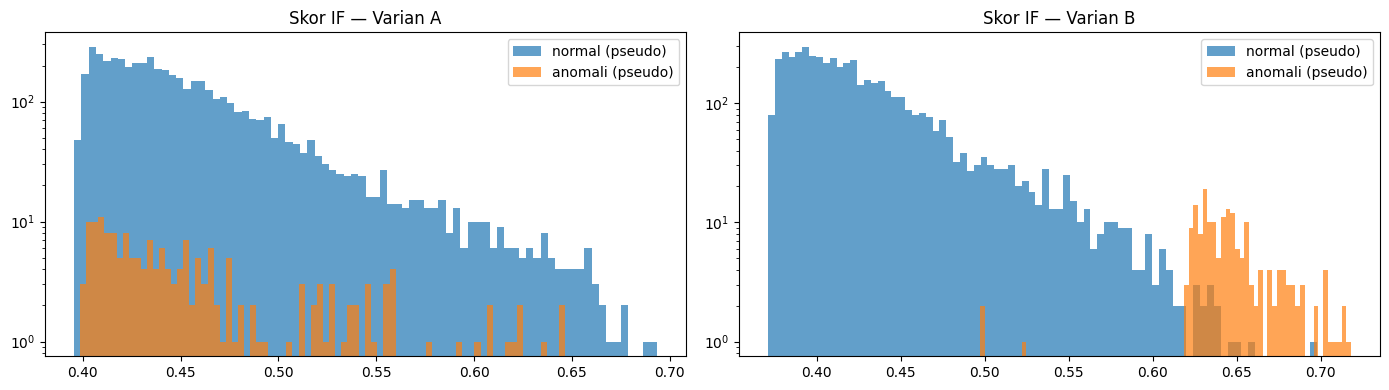

Kandidat anomali baru: 13
      block_index tx_recipient  tx_energy  price_dev  latency_resid  \
167            20       CON-03     1.6456     0.0037        -0.0006   
4185          397       CON-03     3.2857     0.0255        -0.0001   
4872          460       CON-06     1.9856     0.0103         0.0008   
1048          101       CON-14     1.1683     0.0216        -0.0002   
1911          183       CON-03     0.8250     0.0101        -0.0002   
4307          406       CON-12     1.5623     0.0243         0.0001   
4206          400       CON-03     1.1888     0.0056         0.0002   
4020          382       CON-10     1.6638     0.0186         0.0005   
4257          403       CON-11     0.3713     0.0207         0.0002   
173            20       CON-03     1.1017     0.0246        -0.0006   
1912          183       CON-03     2.6335     0.0219        -0.0002   
3759          354       CON-10     0.5233     0.0250         0.0002   
4959          467       CON-04     1.2524     0.025

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, v in zip(axes, ['A', 'B']):
    ax.hist(fe.loc[fe['pseudo_label']==0, f'score_{v}'], bins=80, 
            alpha=0.7, label='normal (pseudo)')
    ax.hist(fe.loc[fe['pseudo_label']==1, f'score_{v}'], bins=80, 
            alpha=0.7, label='anomali (pseudo)')
    ax.set_yscale('log'); ax.set_title(f'Skor IF — Varian {v}')
    ax.legend()
plt.tight_layout(); plt.show()

# Anomali BARU versi Varian B: di-flag model tapi tidak oleh rules — kandidat investigasi
baru = fe[(fe['flag_B']==1) & (fe['pseudo_label']==0)] \
         .sort_values('score_B', ascending=False)
print(f"Kandidat anomali baru: {len(baru)}")
print(baru[['block_index','tx_recipient','tx_energy','price_dev',
            'latency_resid','time_to_pay','score_B']].head(15))

# Cell 22

In [22]:
harga_idx = fe[fe['price_dev'] > 0.20].index
n = len(fe)
for v in ['A', 'B']:
    ranks = fe[f'score_{v}'].rank(ascending=False)[harga_idx]
    print(f"Varian {v} — peringkat skor 3 anomali harga (dari {n}): "
          f"{ranks.astype(int).tolist()}")
print(f"\nSkor mereka di B: {fe.loc[harga_idx, 'score_B'].round(4).tolist()}")
print(f"Threshold flag B (skor ke-182): {fe['score_B'].nlargest(182).min():.4f}")

Varian A — peringkat skor 3 anomali harga (dari 5193): [330, 316, 334]
Varian B — peringkat skor 3 anomali harga (dari 5193): [629, 610, 435]

Skor mereka di B: [0.4972, 0.4992, 0.5243]
Threshold flag B (skor ke-182): 0.6244


In [23]:
fe['log_energy'] = np.log1p(fe['tx_energy'])
feats_C = ['log_energy', 'price_dev', 'latency_resid', 'time_to_pay']

iso_C = IsolationForest(n_estimators=300, max_samples=len(fe),
                        contamination=0.036, random_state=42)
iso_C.fit(fe[feats_C])
fe['score_C'] = -iso_C.score_samples(fe[feats_C])
fe['flag_C'] = (iso_C.predict(fe[feats_C]) == -1).astype(int)

tp = ((fe['flag_C']==1) & (fe['pseudo_label']==1)).sum()
fp = ((fe['flag_C']==1) & (fe['pseudo_label']==0)).sum()
fn = ((fe['flag_C']==0) & (fe['pseudo_label']==1)).sum()
print(f"Varian C: TP={tp} FP={fp} FN={fn}")
print(f"Precision={tp/(tp+fp):.3f}  Recall={tp/(tp+fn):.3f}")

caught = fe[fe['flag_C']==1]
print(f"Tertangkap: {caught['unpaid'].sum()}/181 unpaid, "
      f"{(caught['price_dev']>0.20).sum()}/3 harga")

# Peringkat 3 anomali harga sekarang
print(f"Peringkat harga di C: "
      f"{fe['score_C'].rank(ascending=False)[harga_idx].astype(int).tolist()}")

Varian C: TP=148 FP=39 FN=36
Precision=0.791  Recall=0.804
Tertangkap: 145/181 unpaid, 3/3 harga
Peringkat harga di C: [3, 4, 2]


Evaluasi bebas threshold (berbasis ranking skor):
  Varian A: AP=0.0427  AUC-ROC=0.5081
  Varian B: AP=0.9413  AUC-ROC=0.9977
  Varian C: AP=0.7349  AUC-ROC=0.9945


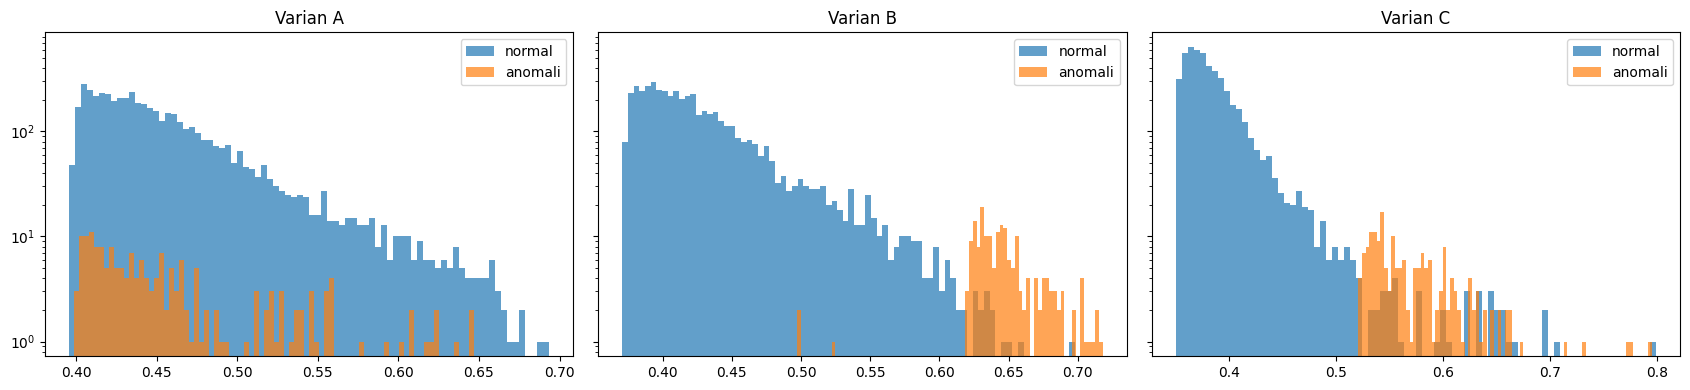

In [24]:
from sklearn.metrics import average_precision_score, roc_auc_score

print("Evaluasi bebas threshold (berbasis ranking skor):")
for v in ['A', 'B', 'C']:
    ap  = average_precision_score(fe['pseudo_label'], fe[f'score_{v}'])
    auc = roc_auc_score(fe['pseudo_label'], fe[f'score_{v}'])
    print(f"  Varian {v}: AP={ap:.4f}  AUC-ROC={auc:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharey=True)
for ax, v in zip(axes, ['A', 'B', 'C']):
    ax.hist(fe.loc[fe['pseudo_label']==0, f'score_{v}'], bins=80, alpha=0.7, label='normal')
    ax.hist(fe.loc[fe['pseudo_label']==1, f'score_{v}'], bins=80, alpha=0.7, label='anomali')
    ax.set_yscale('log'); ax.set_title(f'Varian {v}'); ax.legend()
plt.tight_layout()
plt.savefig('if_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

# 25

In [25]:
for v in ['B', 'C']:
    fe[f'rank_{v}'] = fe[f'score_{v}'].rank(pct=True)
fe['score_ens'] = fe[['rank_B', 'rank_C']].max(axis=1)

ap  = average_precision_score(fe['pseudo_label'], fe['score_ens'])
auc = roc_auc_score(fe['pseudo_label'], fe['score_ens'])
print(f"Ensemble: AP={ap:.4f}  AUC-ROC={auc:.4f}")

# Threshold setara: flag 184 teratas (sesuai estimasi anomali)
fe['flag_ens'] = (fe['score_ens'] >= fe['score_ens'].nlargest(184).min()).astype(int)
caught = fe[fe['flag_ens'] == 1]
print(f"Flag total: {fe['flag_ens'].sum()}")
print(f"Tertangkap: {caught['unpaid'].sum()}/181 unpaid, "
      f"{(caught['price_dev'] > 0.20).sum()}/3 harga")
tp = ((fe['flag_ens']==1) & (fe['pseudo_label']==1)).sum()
print(f"Precision={tp/fe['flag_ens'].sum():.3f}  Recall={tp/184:.3f}")

Ensemble: AP=0.7843  AUC-ROC=0.9953
Flag total: 184
Tertangkap: 146/181 unpaid, 3/3 harga
Precision=0.810  Recall=0.810


                  jumlah  menit_awal  menit_akhir  total_energi  total_nilai
jenis                                                                       
manipulasi harga       3     41.2000     117.2000        0.3528       0.1025
non-payment          181     61.1000     117.1000      204.8162      41.9777


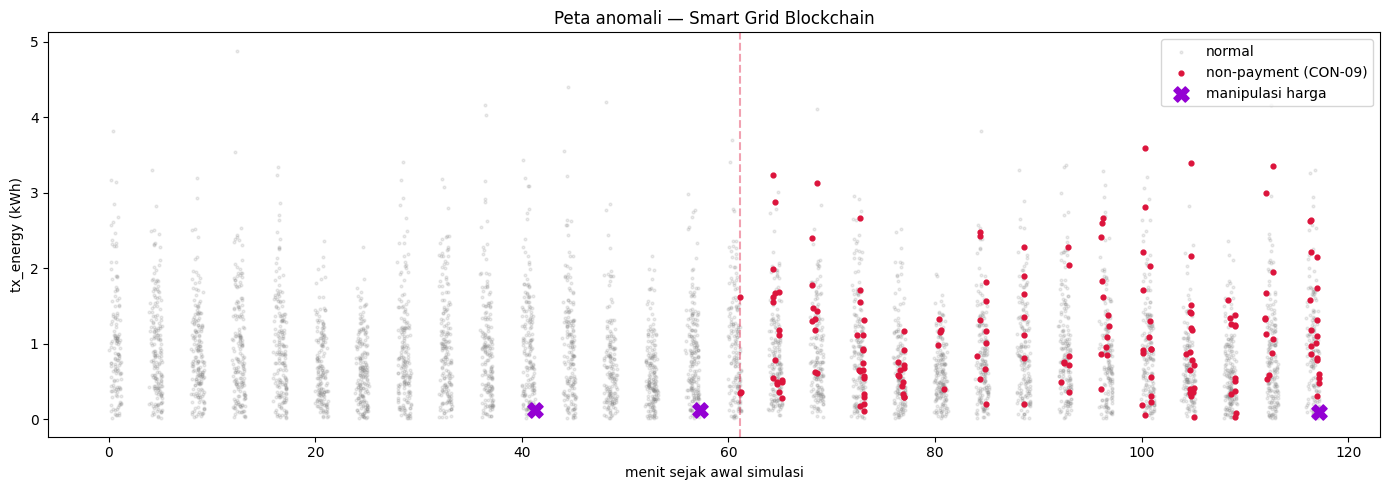

In [26]:
# Satu tabel master semua anomali untuk laporan
registry = fe[fe['pseudo_label']==1].copy()
registry['jenis'] = np.where(registry['unpaid'], 'non-payment', 'manipulasi harga')
registry['menit'] = ((registry['tx_timestamp'] - t0) / 60).round(1)

print(registry.groupby('jenis').agg(
    jumlah=('tx_id', 'count'),
    menit_awal=('menit', 'min'),
    menit_akhir=('menit', 'max'),
    total_energi=('tx_energy', 'sum'),
    total_nilai=('tx_amount', 'sum'),
))

# Visualisasi penutup: peta anomali di ruang waktu × energi
plt.figure(figsize=(14, 5))
normal_pts = fe[fe['pseudo_label']==0]
plt.scatter((normal_pts['tx_timestamp']-t0)/60, normal_pts['tx_energy'],
            s=4, alpha=0.15, color='gray', label='normal')
unp = fe[fe['unpaid']]
plt.scatter((unp['tx_timestamp']-t0)/60, unp['tx_energy'],
            s=12, color='crimson', label='non-payment (CON-09)')
hrg = fe[fe['price_dev']>0.20]
plt.scatter((hrg['tx_timestamp']-t0)/60, hrg['tx_energy'],
            s=120, marker='X', color='darkviolet', label='manipulasi harga')
plt.axvline(61.1, color='crimson', ls='--', alpha=0.4)
plt.xlabel('menit sejak awal simulasi'); plt.ylabel('tx_energy (kWh)')
plt.title('Peta anomali — Smart Grid Blockchain')
plt.legend(); plt.tight_layout()
plt.savefig('peta_anomali.png', dpi=120, bbox_inches='tight')
plt.show()

# 27

In [27]:
ks = [184, 200, 220, 250, 300, 400]
rows = []
for k in ks:
    thr = fe['score_ens'].nlargest(k).min()
    flagged = fe[fe['score_ens'] >= thr]
    tp = flagged['pseudo_label'].sum()
    rows.append({'k_flag': len(flagged), 'TP': tp,
                 'precision': tp/len(flagged), 'recall': tp/184,
                 'unpaid': flagged['unpaid'].sum(),
                 'harga': (flagged['price_dev']>0.20).sum()})
print(pd.DataFrame(rows).to_string(index=False))

 k_flag  TP  precision  recall  unpaid  harga
    184 149     0.8098  0.8098     146      3
    200 163     0.8150  0.8859     160      3
    220 180     0.8182  0.9783     177      3
    250 184     0.7360  1.0000     181      3
    301 184     0.6113  1.0000     181      3
    401 184     0.4589  1.0000     181      3


# Cell 28

In [28]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

feats = ['log_energy', 'price_dev', 'latency_resid', 'time_to_pay']
X = fe[feats].copy()

# StandardScaler hanya untuk OCSVM
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

results = []

# --- IF Varian C (benchmark kita) ---
# Skor sudah ada di fe['score_C'], tinggal ambil
ap  = average_precision_score(fe['pseudo_label'], fe['score_C'])
auc = roc_auc_score(fe['pseudo_label'], fe['score_C'])
results.append({'model': 'Isolation Forest', 'AP': ap, 'AUC': auc,
                'note': 'max_samples=n, log_energy'})

# --- LOF ---
# LOF tidak punya score_samples di mode novelty=False,
# pakai negative_outlier_factor_ sebagai skor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.036)
lof_labels = lof.fit_predict(X)
lof_scores = -lof.negative_outlier_factor_  # besar = makin anomal

fe['score_lof'] = lof_scores
fe['flag_lof']  = (lof_labels == -1).astype(int)

ap  = average_precision_score(fe['pseudo_label'], fe['score_lof'])
auc = roc_auc_score(fe['pseudo_label'], fe['score_lof'])
caught = fe[fe['flag_lof']==1]
results.append({'model': 'LOF (k=20)', 'AP': ap, 'AUC': auc,
                'note': f"unpaid={caught['unpaid'].sum()}/181, "
                        f"harga={(caught['price_dev']>0.20).sum()}/3"})

# Coba juga k=50 — LOF sensitif terhadap k
lof50 = LocalOutlierFactor(n_neighbors=50, contamination=0.036)
lof50_labels = lof50.fit_predict(X)
lof50_scores = -lof50.negative_outlier_factor_
fe['score_lof50'] = lof50_scores
ap50  = average_precision_score(fe['pseudo_label'], fe['score_lof50'])
auc50 = roc_auc_score(fe['pseudo_label'], fe['score_lof50'])
caught50 = fe[(lof50_labels==-1)]
results.append({'model': 'LOF (k=50)', 'AP': ap50, 'AUC': auc50,
                'note': f"unpaid={fe[(lof50_labels==-1)&fe['unpaid']].shape[0]}/181, "
                        f"harga={fe[(lof50_labels==-1)&(fe['price_dev']>0.20)].shape[0]}/3"})

# --- OCSVM ---
# nu ≈ contamination
ocsvm = OneClassSVM(kernel='rbf', nu=0.036, gamma='scale')
ocsvm.fit(X_scaled)
ocsvm_scores = -ocsvm.score_samples(X_scaled)  # besar = makin anomal
ocsvm_labels = ocsvm.predict(X_scaled)

fe['score_ocsvm'] = ocsvm_scores
fe['flag_ocsvm']  = (ocsvm_labels == -1).astype(int)

ap  = average_precision_score(fe['pseudo_label'], fe['score_ocsvm'])
auc = roc_auc_score(fe['pseudo_label'], fe['score_ocsvm'])
caught = fe[fe['flag_ocsvm']==1]
results.append({'model': 'One-Class SVM (rbf)', 'AP': ap, 'AUC': auc,
                'note': f"unpaid={caught['unpaid'].sum()}/181, "
                        f"harga={(caught['price_dev']>0.20).sum()}/3"})

print(pd.DataFrame(results).to_string(index=False))

              model     AP    AUC                      note
   Isolation Forest 0.7349 0.9945 max_samples=n, log_energy
         LOF (k=20) 0.1072 0.5585  unpaid=20/181, harga=3/3
         LOF (k=50) 0.1938 0.5482  unpaid=48/181, harga=3/3
One-Class SVM (rbf) 0.1675 0.7201  unpaid=56/181, harga=3/3


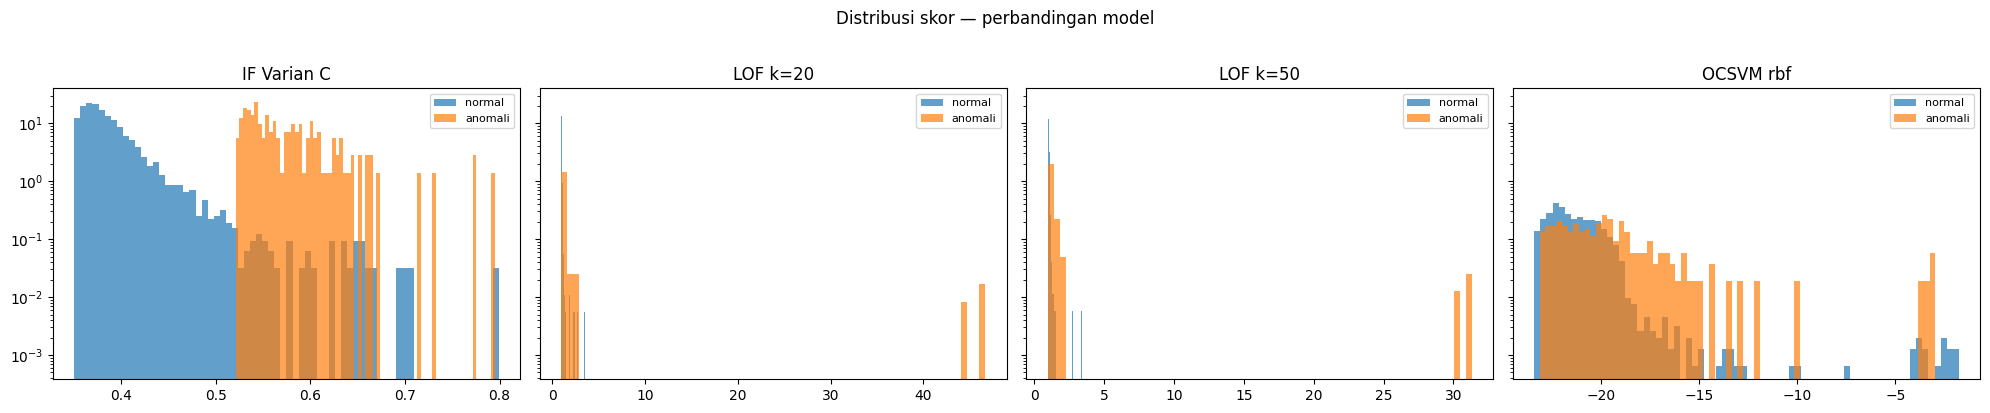

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
pairs = [('score_C', 'IF Varian C'), ('score_lof', 'LOF k=20'),
         ('score_lof50', 'LOF k=50'), ('score_ocsvm', 'OCSVM rbf')]

for ax, (col, title) in zip(axes, pairs):
    ax.hist(fe.loc[fe['pseudo_label']==0, col], bins=70,
            alpha=0.7, label='normal', density=True)
    ax.hist(fe.loc[fe['pseudo_label']==1, col], bins=70,
            alpha=0.7, label='anomali', density=True)
    ax.set_yscale('log')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('Distribusi skor — perbandingan model', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

# Cell 30

In [30]:
# Gabungkan delivery dan payment untuk agregasi blok
tx_all = tx.copy()
tx_all['t_rel'] = tx_all['tx_timestamp'] - t0

# Agregasi per blok
block_agg = tx_all.groupby('block_index').agg(
    block_timestamp=('block_timestamp', 'first'),
    n_tx=('tx_id', 'count'),
    n_delivery=('tx_type', lambda x: (x == 'energy_delivery').sum()),
    n_payment=('tx_type', lambda x: (x == 'energy_payment').sum()),
    total_energy=('tx_energy', 'sum'),
    mean_amount=('tx_amount', 'mean'),
    mean_latency=('latency', 'mean'),
).reset_index()

block_agg['t_rel_min'] = (block_agg['block_timestamp'] - t0) / 60
block_agg['payment_ratio'] = (
    block_agg['n_payment'] / block_agg['n_delivery'].replace(0, np.nan)
).fillna(0)

print(f"Blok: {len(block_agg)}")
print(block_agg.describe().T[['mean','std','min','max']])

Blok: 489
                              mean        std                min  \
block_index               245.0000   141.3064             1.0000   
block_timestamp 1,753,188,337.9961 2,065.2338 1,753,184,805.0684   
n_tx                       20.8691    10.1222             2.0000   
n_delivery                 10.6196     5.0816             1.0000   
n_payment                  10.2495     5.1021             0.0000   
total_energy                9.2959     5.1613             0.1015   
mean_amount                 0.1764     0.0660             0.0204   
mean_latency                0.0073     0.0048             0.0003   
t_rel_min                  58.8821    34.4206             0.0000   
payment_ratio               0.9634     0.1217             0.0000   

                               max  
block_index               489.0000  
block_timestamp 1,753,191,838.3442  
n_tx                       48.0000  
n_delivery                 24.0000  
n_payment                  24.0000  
total_energy       

In [31]:
# Window ±10 blok (±~2.5 menit) — cukup untuk smooth siklus tapi tidak menghapus anomali lokal
WINDOW = 21  # 10 kiri + titik tengah + 10 kanan

block_feats = ['n_tx', 'total_energy', 'payment_ratio', 'mean_latency']

for feat in block_feats:
    roll_mean = block_agg[feat].rolling(WINDOW, center=True, min_periods=5).mean()
    roll_std  = block_agg[feat].rolling(WINDOW, center=True, min_periods=5).std()
    block_agg[f'z_{feat}'] = (block_agg[feat] - roll_mean) / roll_std.replace(0, np.nan)

# Skor anomali blok: max z-score absolut di antara semua fitur
z_cols = [f'z_{f}' for f in block_feats]
block_agg['z_max'] = block_agg[z_cols].abs().max(axis=1)
block_agg['anomaly_block'] = block_agg['z_max'] > 3.0  # threshold 3-sigma

print(f"Blok anomal (|z| > 3): {block_agg['anomaly_block'].sum()}")
print("\nBlok anomal teratas:")
print(block_agg[block_agg['anomaly_block']]
      [['block_index','t_rel_min','n_tx','total_energy',
        'payment_ratio','mean_latency','z_max']]
      .sort_values('z_max', ascending=False)
      .head(15).to_string(index=False))

Blok anomal (|z| > 3): 5

Blok anomal teratas:
 block_index  t_rel_min  n_tx  total_energy  payment_ratio  mean_latency  z_max
         368    88.5694    29       21.3142         0.6111        0.0134 4.3644
         322    76.9592    16        7.8632         0.4545        0.0118 3.9951
         355    84.8974    15       10.3981         0.5000        0.0183 3.6400
         265    64.2679    11       10.0903         0.5714        0.0072 3.2353
          89    20.6969    34       12.7650         1.0000        0.0047 3.0138


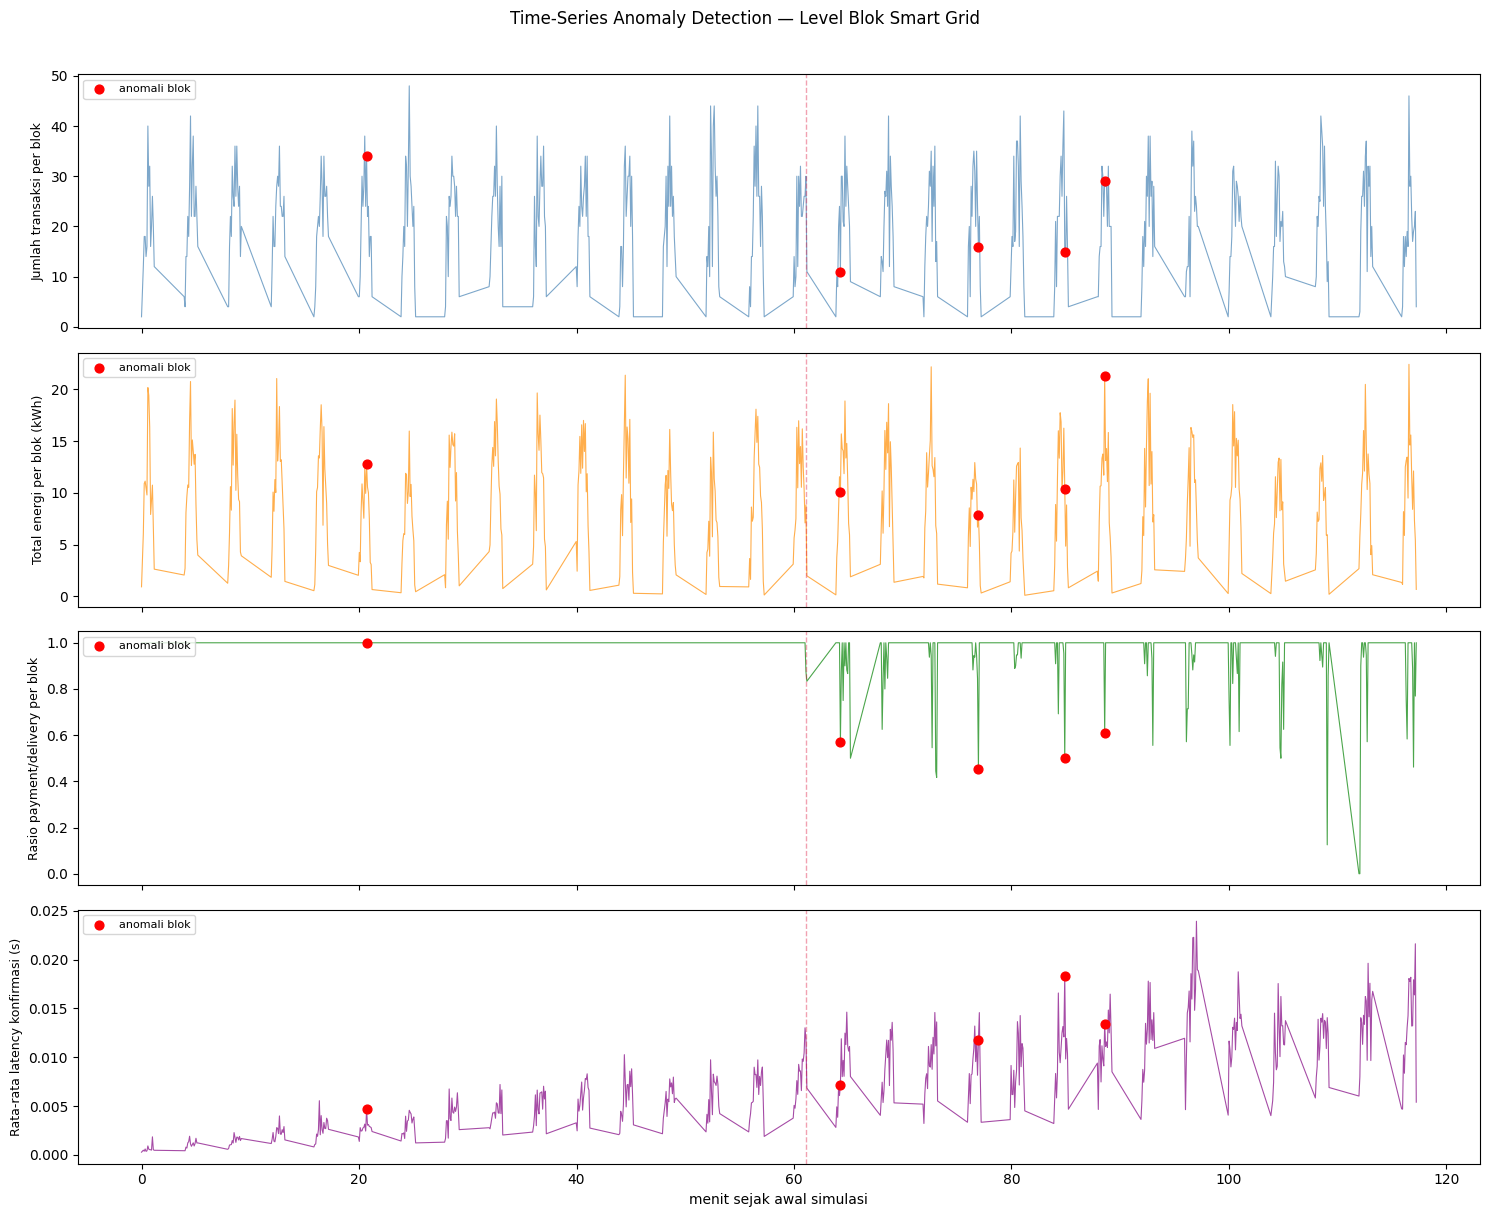

In [32]:
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

configs = [
    ('n_tx', 'Jumlah transaksi per blok', 'steelblue'),
    ('total_energy', 'Total energi per blok (kWh)', 'darkorange'),
    ('payment_ratio', 'Rasio payment/delivery per blok', 'green'),
    ('mean_latency', 'Rata-rata latency konfirmasi (s)', 'purple'),
]

for ax, (feat, ylabel, color) in zip(axes, configs):
    ax.plot(block_agg['t_rel_min'], block_agg[feat],
            color=color, alpha=0.7, lw=0.8)

    # Highlight blok anomal
    anom = block_agg[block_agg['anomaly_block']]
    ax.scatter(anom['t_rel_min'], anom[feat],
               color='red', s=40, zorder=5, label='anomali blok')

    # Garis CON-09
    ax.axvline(61.1, color='crimson', ls='--', alpha=0.4, lw=1)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=8, loc='upper left')

axes[-1].set_xlabel('menit sejak awal simulasi')
fig.suptitle('Time-Series Anomaly Detection — Level Blok Smart Grid',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('timeseries_anomaly.png', dpi=120, bbox_inches='tight')
plt.show()

In [33]:
# Blok mana yang anomal DAN mengandung transaksi CON-09 tak berbayar?
con9_blocks = set(fe[fe['unpaid']]['block_index'].unique())
anom_blocks  = set(block_agg[block_agg['anomaly_block']]['block_index'].unique())

overlap = con9_blocks & anom_blocks
only_anom = anom_blocks - con9_blocks  # anomali blok tanpa CON-09 — kandidat temuan baru

print(f"Blok anomal total: {len(anom_blocks)}")
print(f"Blok anomal yang mengandung unpaid CON-09: {len(overlap)}")
print(f"Blok anomal tanpa CON-09 (kandidat baru): {len(only_anom)}")

if only_anom:
    print("\nDetail blok anomal tanpa CON-09:")
    print(block_agg[block_agg['block_index'].isin(only_anom)]
          [['block_index','t_rel_min','n_tx','total_energy',
            'payment_ratio','z_max']].to_string(index=False))

Blok anomal total: 5
Blok anomal yang mengandung unpaid CON-09: 4
Blok anomal tanpa CON-09 (kandidat baru): 1

Detail blok anomal tanpa CON-09:
 block_index  t_rel_min  n_tx  total_energy  payment_ratio  z_max
          89    20.6969    34       12.7650         1.0000 3.0138


# Cell 34

In [34]:
# Install jika belum ada
import subprocess
subprocess.run(['pip', 'install', 'shap', '--quiet', '--break-system-packages'], 
               capture_output=True)

import shap

# Pakai IF Varian C (model final terpilih dari perbandingan)
# Rebuild dulu karena objek iso_C dari Cell 23
feats_C = ['log_energy', 'price_dev', 'latency_resid', 'time_to_pay']
iso_C_final = IsolationForest(n_estimators=300, max_samples=len(fe),
                               contamination=0.036, random_state=42)
iso_C_final.fit(fe[feats_C])

# TreeExplainer untuk tree-based model — eksak, bukan sampling
explainer = shap.TreeExplainer(iso_C_final)
shap_values = explainer.shap_values(fe[feats_C])

# shap_values shape: (n_samples, n_features)
print(f"Shape SHAP values: {shap_values.shape}")
print(f"\nMean |SHAP| per fitur (kontribusi rata-rata ke anomali score):")
mean_abs = pd.Series(np.abs(shap_values).mean(axis=0), 
                     index=feats_C).sort_values(ascending=False)
print(mean_abs)

Shape SHAP values: (5193, 4)

Mean |SHAP| per fitur (kontribusi rata-rata ke anomali score):
time_to_pay     0.8402
log_energy      0.7009
price_dev       0.5313
latency_resid   0.5169
dtype: float64


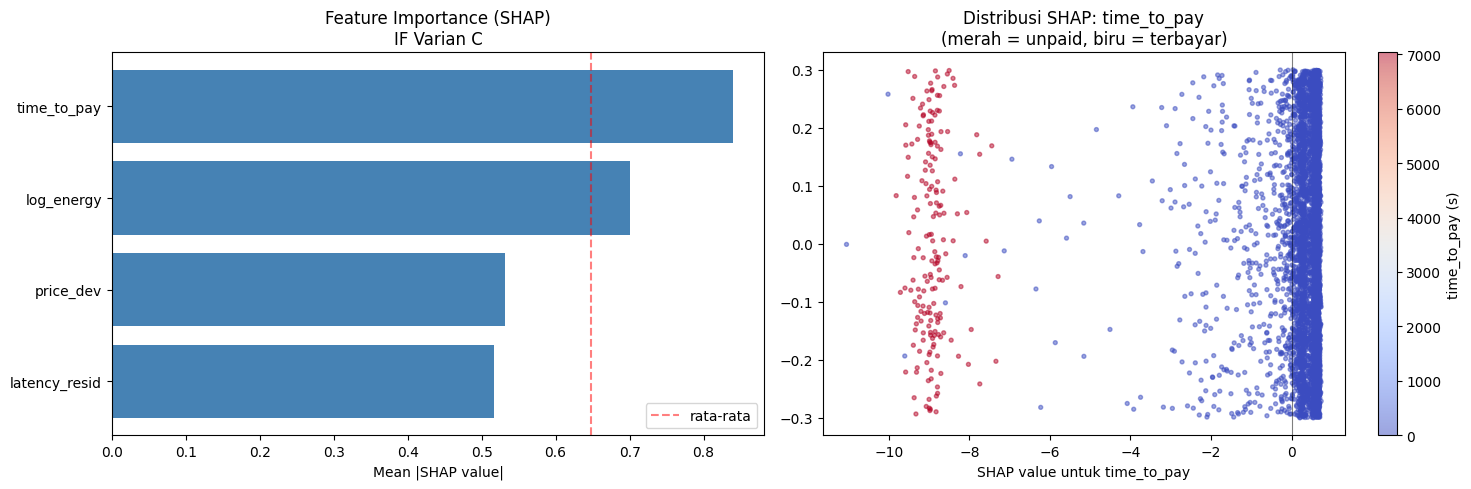

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Bar chart mean |SHAP| — feature importance
axes[0].barh(mean_abs.index[::-1], mean_abs.values[::-1], color='steelblue')
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title('Feature Importance (SHAP)\nIF Varian C')
axes[0].axvline(mean_abs.mean(), color='red', ls='--', alpha=0.5, 
                label='rata-rata')
axes[0].legend()

# Plot 2: SHAP scatter per fitur — warna = nilai fitur
# Manual scatter supaya tidak perlu shap.summary_plot (lebih kontrol)
colors = plt.cm.coolwarm(
    (fe['time_to_pay'] - fe['time_to_pay'].min()) / 
    (fe['time_to_pay'].max() - fe['time_to_pay'].min())
)
sc = axes[1].scatter(shap_values[:, feats_C.index('time_to_pay')],
                     np.random.uniform(-0.3, 0.3, len(fe)),  # jitter y
                     c=fe['time_to_pay'], cmap='coolwarm', 
                     s=8, alpha=0.5)
plt.colorbar(sc, ax=axes[1], label='time_to_pay (s)')
axes[1].set_xlabel('SHAP value untuk time_to_pay')
axes[1].set_title('Distribusi SHAP: time_to_pay\n(merah = unpaid, biru = terbayar)')
axes[1].axvline(0, color='black', lw=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('shap_global.png', dpi=120, bbox_inches='tight')
plt.show()

Mean SHAP per kelompok (positif = mendorong ke anomali):

                      log_energy  price_dev  latency_resid  time_to_pay
Normal                    0.0021     0.0199        -0.0103       0.3196
Non-payment (CON-09)     -0.0802     0.0414         0.0475      -8.9072
Manipulasi harga         -1.4254   -15.1252         0.1380       0.1334


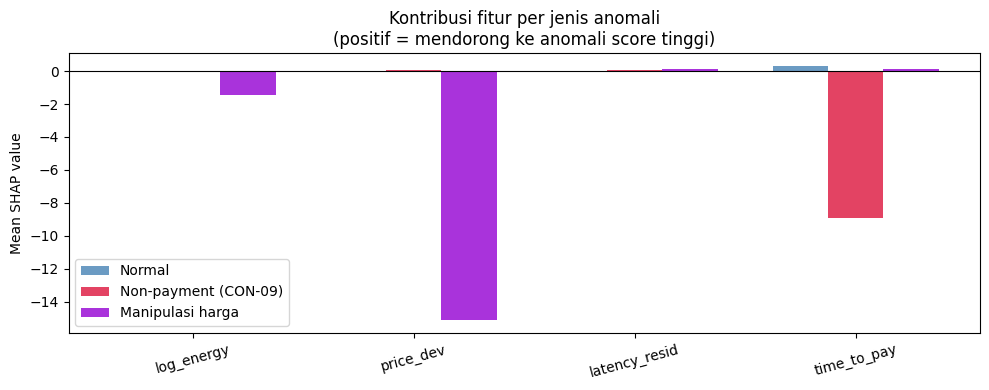

In [36]:
# Rata-rata SHAP untuk tiap kelompok
groups = {
    'Normal': fe['pseudo_label'] == 0,
    'Non-payment (CON-09)': fe['unpaid'],
    'Manipulasi harga': fe['price_dev'] > 0.20,
}

shap_df = pd.DataFrame(shap_values, columns=feats_C)

print("Mean SHAP per kelompok (positif = mendorong ke anomali):\n")
summary = {}
for nama, mask in groups.items():
    summary[nama] = shap_df[mask.values].mean()
    
summary_df = pd.DataFrame(summary).T
print(summary_df.round(6))

# Visualisasi: grouped bar
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(feats_C))
width = 0.25
colors_g = ['steelblue', 'crimson', 'darkviolet']

for i, (nama, _) in enumerate(groups.items()):
    vals = summary_df.loc[nama, feats_C].values
    ax.bar(x + i*width, vals, width, label=nama, 
           color=colors_g[i], alpha=0.8)

ax.set_xticks(x + width)
ax.set_xticklabels(feats_C, rotation=15)
ax.set_ylabel('Mean SHAP value')
ax.set_title('Kontribusi fitur per jenis anomali\n(positif = mendorong ke anomali score tinggi)')
ax.axhline(0, color='black', lw=0.8)
ax.legend()
plt.tight_layout()
plt.savefig('shap_per_jenis.png', dpi=120, bbox_inches='tight')
plt.show()

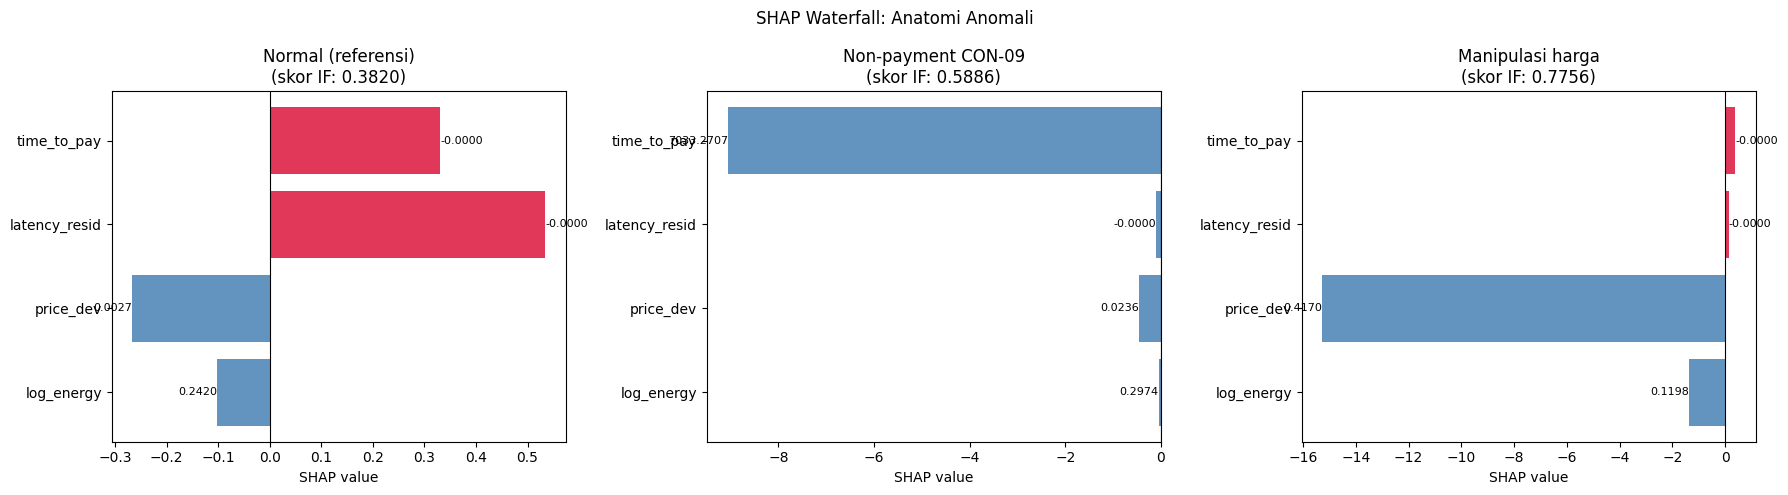

In [37]:
# Pilih satu contoh tiap jenis untuk "kartu identitas anomali"
idx_con9  = fe[fe['unpaid']].index[0]   # unpaid pertama
idx_harga = fe[fe['price_dev'] > 0.20].index[0]  # harga anomal pertama
idx_normal = fe[fe['pseudo_label'] == 0].index[100]  # normal representatif

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Normal (referensi)', 'Non-payment CON-09', 'Manipulasi harga']
idxs   = [idx_normal, idx_con9, idx_harga]

for ax, idx, title in zip(axes, idxs, titles):
    vals = shap_values[fe.index.get_loc(idx)]
    feat_vals = fe[feats_C].iloc[fe.index.get_loc(idx)]
    
    colors_bar = ['crimson' if v > 0 else 'steelblue' for v in vals]
    bars = ax.barh(feats_C, vals, color=colors_bar, alpha=0.85)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'{title}\n(skor IF: {fe["score_C"].iloc[fe.index.get_loc(idx)]:.4f})')
    ax.set_xlabel('SHAP value')
    
    # Anotasi nilai fitur
    for bar, fval in zip(bars, feat_vals):
        ax.text(bar.get_width() + 0.0002 if bar.get_width() >= 0 
                else bar.get_width() - 0.0002,
                bar.get_y() + bar.get_height()/2,
                f'{fval:.4f}', va='center', 
                ha='left' if bar.get_width() >= 0 else 'right',
                fontsize=8)

plt.suptitle('SHAP Waterfall: Anatomi Anomali', fontsize=12)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=120, bbox_inches='tight')
plt.show()